#**Project Title**

**AI-Powered Cyber Risk Scoring Engine**

**A Data Science + GRC Project for Predicting Enterprise Cyber Risk**

### **1. Project Positioning**

**This project shows how to combine:**

- Cybersecurity GRC

- Risk quantification

- Machine learning

- Business analytics

- Executive communication

**It is especially strong for roles such as:**

- Cybersecurity GRC Analyst

- Cyber Risk Analyst

- Technology Risk Analyst

- Third-Party Risk Analyst

- AI Governance Analyst

- Cybersecurity Consultant

### **2. Business Problem**

Organizations often assess cyber risk using manual spreadsheets, subjective ratings, and static compliance reviews. That approach is slow, inconsistent, and hard to scale.

This project builds a machine learning-based risk scoring engine that predicts whether a system, asset, or vendor is likely to fall into a Low, Medium, High, or Critical cyber risk category based on operational, vulnerability, and compliance-related features.

### **3. Portfolio Outcome**

By the end of this project, you will have:

a clean dataset

a full Python notebook

a trained classification model

feature importance analysis

confusion matrix

ROC/AUC evaluation

business recommendations

### **4. Dataset Design**

Since many real enterprise cyber datasets are private, this project can begin with a realistic simulated dataset.

Features

Each row represents a system, application, server, or vendor profile.

asset_id

cvss_score — vulnerability severity

patch_delay_days — average time to patch vulnerabilities

incident_frequency — number of incidents in recent period

system_criticality — importance of the asset

third_party_risk_score — vendor or supply chain risk

compliance_score — control maturity/compliance level

failed_login_rate — suspicious login activity

data_sensitivity — sensitivity of data handled

open_findings — unresolved security findings

risk_score — continuous computed score

risk_level — target label: Low / Medium / High / Critical

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1500

asset_ids = [f"AST-{i:04d}" for i in range(1, n + 1)]

cvss_score = np.round(np.random.uniform(0.0, 10.0, n), 2)
patch_delay_days = np.random.randint(0, 181, n)
incident_frequency = np.random.poisson(lam=2.5, size=n)
system_criticality = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.1, 0.2, 0.3, 0.25, 0.15])
third_party_risk_score = np.round(np.random.uniform(0, 100, n), 2)
compliance_score = np.round(np.random.uniform(40, 100, n), 2)
failed_login_rate = np.round(np.random.uniform(0, 50, n), 2)
data_sensitivity = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.15, 0.2, 0.25, 0.25, 0.15])
open_findings = np.random.randint(0, 21, n)

# Weighted synthetic risk score
risk_score = (
    cvss_score * 8
    + patch_delay_days * 0.18
    + incident_frequency * 7
    + system_criticality * 8
    + third_party_risk_score * 0.20
    - compliance_score * 0.35
    + failed_login_rate * 0.45
    + data_sensitivity * 6
    + open_findings * 2.2
)

risk_score = np.round(risk_score, 2)

def label_risk(score):
    if score < 45:
        return "Low"
    elif score < 75:
        return "Medium"
    elif score < 105:
        return "High"
    return "Critical"

risk_level = [label_risk(score) for score in risk_score]

df = pd.DataFrame({
    "asset_id": asset_ids,
    "cvss_score": cvss_score,
    "patch_delay_days": patch_delay_days,
    "incident_frequency": incident_frequency,
    "system_criticality": system_criticality,
    "third_party_risk_score": third_party_risk_score,
    "compliance_score": compliance_score,
    "failed_login_rate": failed_login_rate,
    "data_sensitivity": data_sensitivity,
    "open_findings": open_findings,
    "risk_score": risk_score,
    "risk_level": risk_level
})

df.to_csv("cyber_risk_dataset_generated.csv", index=False)
print(df.head())
print("\nDataset saved as cyber_risk_dataset_generated.csv")

   asset_id  cvss_score  patch_delay_days  incident_frequency  \
0  AST-0001        3.75                47                   0   
1  AST-0002        9.51               155                   2   
2  AST-0003        7.32               116                   0   
3  AST-0004        5.99               153                   5   
4  AST-0005        1.56               152                   2   

   system_criticality  third_party_risk_score  compliance_score  \
0                   5                   13.92             44.75   
1                   3                   23.70             79.39   
2                   3                   44.80             41.11   
3                   1                   18.89             89.91   
4                   1                   26.86             50.48   

   failed_login_rate  data_sensitivity  open_findings  risk_score risk_level  
0               6.67                 5             14      129.38   Critical  
1              44.00                 4          

###**Insights and Observation**

**🔍 What’s happening**

A dataset was created with:

- vulnerabilities (CVSS)

- patch delays

- incidents

- compliance

- risk score + label

**👉 Example:**

High CVSS + long patch delay + low compliance → Critical risk

###**💡 Why it’s important?**

- Real cybersecurity data is confidential, so a simulated, realistic enterprise environment is crucial. why?

- To understand what drives cyber risk

- To quantify it (with numbers)

**🔥 Key Insight**

👉 we didn’t just build a dataset —
we built **a risk logic model (like NIST thinking)**

###**Step 1: Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

###**Step 2: Load Data**

In [ ]:
df = pd.read_csv("/content/cyber_risk_dataset_generated.csv")
df.head()

,asset_id,cvss_score,patch_delay_days,incident_frequency,system_criticality,third_party_risk_score,compliance_score,failed_login_rate,data_sensitivity,open_findings,risk_score,risk_level
0,AST-0001,3.75,47,0,5,13.92,44.75,6.67,5,14,129.38,Critical
1,AST-0002,9.51,155,2,3,23.70,79.39,44.00,4,13,191.33,Critical
2,AST-0003,7.32,116,0,3,44.80,41.11,25.54,3,6,140.70,Critical
3,AST-0004,5.99,153,5,1,18.89,89.91,4.11,3,4,119.42,Critical
4,AST-0005,1.56,152,2,1,26.86,50.48,30.84,5,19,135.22,Critical


###**Insights and Interpretation (Same with step 3)**

**🔍 What’s happening**


- Loaded the dataset

- Viewed structure (columns, types)

- Checked data quality

###**💡 Why it’s important?**

**Before modeling, you must ensure:**

- No missing values

- Correct data types

- Balanced structure

**🔥 Key Insight**

👉 “Garbage in = garbage out”

**Good models start with clean data**

###**Step 3: Inspect Data**

In [ ]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["risk_level"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   asset_id                1500 non-null   object 
 1   cvss_score              1500 non-null   float64
 2   patch_delay_days        1500 non-null   int64  
 3   incident_frequency      1500 non-null   int64  
 4   system_criticality      1500 non-null   int64  
 5   third_party_risk_score  1500 non-null   float64
 6   compliance_score        1500 non-null   float64
 7   failed_login_rate       1500 non-null   float64
 8   data_sensitivity        1500 non-null   int64  
 9   open_findings           1500 non-null   int64  
 10  risk_score              1500 non-null   float64
 11  risk_level              1500 non-null   object 
dtypes: float64(5), int64(5), object(2)
memory usage: 140.8+ KB
None

Missing values:
 asset_id                  0
cvss_score                0
patch_de

###**Step 4: Visualize Class Distribution**

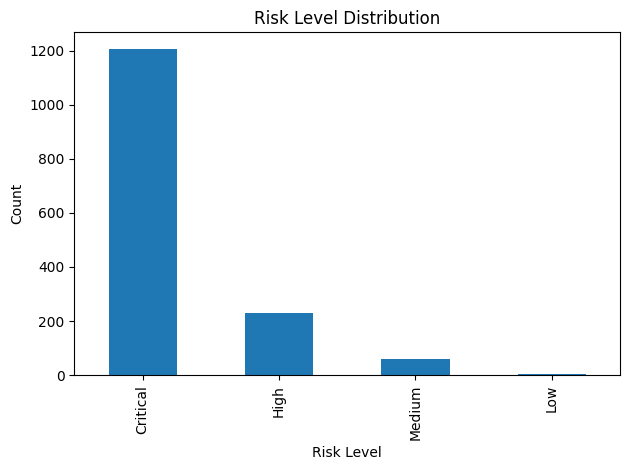

In [ ]:
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

###**Insights and Interpretation**

**🔍 What’s happening**

we plotted how many samples belong to each risk level.

**👉 Result:**

- Critical dominates (~1200)

- Very few Low / Medium

### **💡 Why it’s important?**

- This reveals class imbalance

- 🚨 Critical Insight (VERY IMPORTANT)

- the model is biased toward Critical

**That’s why:**

- Low = 0% accuracy

- Medium = poor recall

**🔥Insight**

👉 “The dataset is highly imbalanced, which impacts model performance for minority classes.”

###**Step 5: Prepare Features and Target**

In [ ]:
X = df.drop(columns=["asset_id", "risk_score", "risk_level"])
y = df["risk_level"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Encoded classes:", dict(zip(le.classes_, range(len(le.classes_)))))

Encoded classes: {'Critical': 0, 'High': 1, 'Low': 2, 'Medium': 3}


###**Insights and Interpretation**

**🔍 What’s happening**

- Features (X) = inputs

- Target (y) = risk_level

- Labels converted to numbers

###**💡 Why it’s important?**

- Machine learning models only understand numbers

**🔥 Key Insight**

👉 we transformed business categories into predictable signals

###**Step 6: Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

###**Insights and Interpretation**

**🔍 What’s happening**

- 80% training

- 20% testing

- Stratified (keeps class proportions)

###**💡 Why it’s important?**

To Prevents:

- Overfitting

- Fake performance

**🔥 Key Insight**

👉 we are testing real-world performance, **not memorization**

###**Step 7: Train Model**

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

###**Insights and Interpretation**

**🔍 What’s happening**

we trained:

- 👉 Random Forest Classifier

- 200 trees

- Controlled depth

- Reduced overfitting

###**💡 Why it’s important?**

**Random Forest:**

- Handles complex relationships

- Works well for tabular risk data

**🔥 Key Insight**

👉 This mimics how real companies model risk scoring systems

###**Step 8: Predictions**

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

###**Insights and Interpretation**

**🔍 What’s happening**

- Model predicts risk levels

- Also outputs probabilities

###**💡 Why it’s important?**

This is where AI becomes:

**👉 decision support**

**🔥 Key Insight**

👉 We moved from data → actionable risk classification

###**Step 9: Classification Report**

In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    Critical       0.91      0.97      0.94       241
        High       0.58      0.48      0.52        46
         Low       0.00      0.00      0.00         1
      Medium       0.60      0.25      0.35        12

    accuracy                           0.86       300
   macro avg       0.52      0.42      0.45       300
weighted avg       0.84      0.86      0.85       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###**Insights and Interpretation**

**🔍 What’s happening**

| Class    | Performance          |
| -------- | -------------------- |
| Critical | Excellent (F1 ~0.94) |
| High     | Moderate             |
| Medium   | Weak                 |
| Low      | Failed               |

###**💡 Why it’s important?**

To show:

- Precision = correctness

- Recall = coverage

- F1 = balance

**🚨 Critical Insight**

The model:
- 👉 overfits dominant class (Critical)
- 👉 struggles with rare classes

**🔥Insight**

👉 “The model performs well on dominant risk classes but struggles with minority classes due to imbalance.”

###**Step 10: Confusion Matrix**

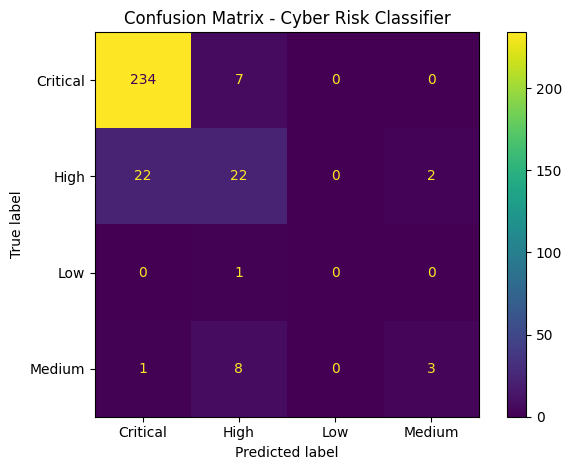

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("Confusion Matrix - Cyber Risk Classifier")
plt.tight_layout()
plt.show()

###**Insights and Interpretation**

**🔍 What’s happening**

Shows:

- True vs predicted labels

###**💡 Key Observations**

- Critical → predicted very well

- High → often misclassified as Critical

- Medium → often misclassified

- Low → almost never detected

**🔥 Key Insight**

👉 Model is biased toward predicting higher risk

**💼 Business Meaning**

👉 Safer than underestimating risk
BUT:

Can cause false alarms / resource waste

###**Step 11: Feature Importance**

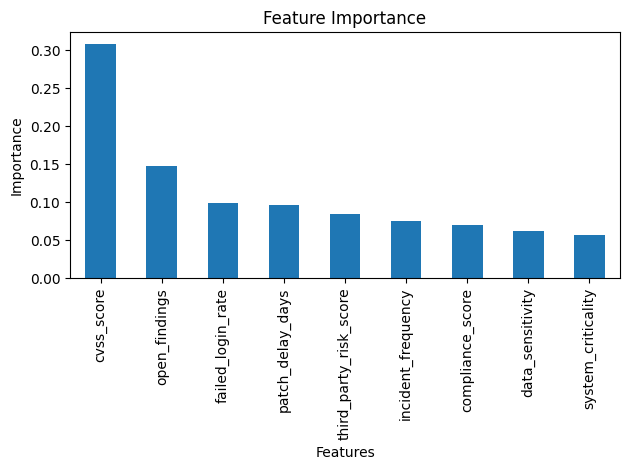

cvss_score                0.308433
open_findings             0.147897
failed_login_rate         0.098357
patch_delay_days          0.096177
third_party_risk_score    0.084634
incident_frequency        0.075719
compliance_score          0.069987
data_sensitivity          0.061434
system_criticality        0.057362
dtype: float64


In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

feature_importances.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print(feature_importances)

###**Insights and Interpretation**

🔍 What’s happening

Top drivers:

CVSS score 🔥

Open findings

Failed login rate

Patch delay

###**💡 Why it’s important?**

To shows:

- 👉 “What actually drives cyber risk”

**🔥 Key Insight**

- Vulnerabilities (CVSS) dominate

- Operational issues (patching, findings) matter

- Behavior (logins) matters

**💼 Real-World Meaning**

Matches:

- NIST

- SOC practices

- Security operations priorities

###**Step 12: Permutation Importance**

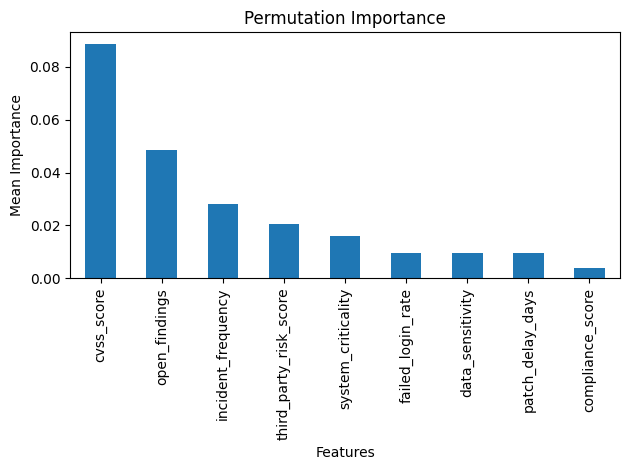

cvss_score                0.088667
open_findings             0.048667
incident_frequency        0.028000
third_party_risk_score    0.020333
system_criticality        0.016000
failed_login_rate         0.009667
data_sensitivity          0.009667
patch_delay_days          0.009333
compliance_score          0.004000
dtype: float64


In [ ]:
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=False)

perm_df.plot(kind="bar")
plt.title("Permutation Importance")
plt.xlabel("Features")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()

print(perm_df)

###**Insight and Interpretation**

**🔍 What’s happening**

Measures:

- 👉 “What happens if we remove this feature?”

###**💡 Why it’s important?**

- More reliable than default importance

**🔥 Key Insight**

- CVSS still #1

- Incident frequency becomes more important

- Confirms model robustness

**💼 Business Meaning**

👉 Multiple factors drive risk — not just vulnerabilities

###**Step 13: Multiclass ROC-AUC**

In [ ]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

auc_score = roc_auc_score(y_test_bin, y_proba, multi_class="ovr")
print("Multiclass ROC-AUC:", round(auc_score, 4))

Multiclass ROC-AUC: 0.9449


###**Insights and Interpretation**

**🔍 What’s happening**

Measures model’s ability to distinguish classes

###**💡 Why it’s important?**

- 0.5 = random

- 1.0 = perfect

**🔥 Key Insight**

- 👉 **0.9449** = excellent model performance overall

⚠️ BUT

**Still hides:**
👉 imbalance problem

###**Step 14: Score New Example Assets**

In [ ]:
new_assets = pd.DataFrame({
    "cvss_score": [9.1, 4.3, 7.5],
    "patch_delay_days": [120, 10, 75],
    "incident_frequency": [6, 1, 4],
    "system_criticality": [5, 2, 4],
    "third_party_risk_score": [85, 30, 70],
    "compliance_score": [50, 92, 65],
    "failed_login_rate": [40, 5, 25],
    "data_sensitivity": [5, 2, 4],
    "open_findings": [12, 1, 8]
})

predictions = model.predict(new_assets)
prediction_labels = le.inverse_transform(predictions)

new_assets["predicted_risk_level"] = prediction_labels
new_assets

,cvss_score,patch_delay_days,incident_frequency,system_criticality,third_party_risk_score,compliance_score,failed_login_rate,data_sensitivity,open_findings,predicted_risk_level
0,9.1,120,6,5,85,50,40,5,12,Critical
1,4.3,10,1,2,30,92,5,2,1,High
2,7.5,75,4,4,70,65,25,4,8,Critical


###**Insights and Interpretation**

**🔍 What’s happening**

- we tested real-like scenarios

**💡 Results**

- Asset 1 → Critical

- Asset 2 → High

- Asset 3 → Critical

### **💼 Why it’s important?**

This is the real use case

- 👉 Analysts input system data → get risk level

**🔥 Key Insight**

👉 This becomes a decision engine

###**15. XGBoost Version**

In [ ]:
!pip install xgboost

In [ ]:
new_assets = pd.DataFrame({
    "cvss_score": [9.1, 4.3, 7.5],
    "patch_delay_days": [120, 10, 75],
    "incident_frequency": [6, 1, 4],
    "system_criticality": [5, 2, 4],
    "third_party_risk_score": [85, 30, 70],
    "compliance_score": [50, 92, 65],
    "failed_login_rate": [40, 5, 25],
    "data_sensitivity": [5, 2, 4],
    "open_findings": [12, 1, 8]
})

predictions = model.predict(new_assets)
prediction_labels = le.inverse_transform(predictions)

new_assets["predicted_risk_level"] = prediction_labels
new_assets

,cvss_score,patch_delay_days,incident_frequency,system_criticality,third_party_risk_score,compliance_score,failed_login_rate,data_sensitivity,open_findings,predicted_risk_level
0,9.1,120,6,5,85,50,40,5,12,Critical
1,4.3,10,1,2,30,92,5,2,1,High
2,7.5,75,4,4,70,65,25,4,8,Critical


###**Insights and Interpretation**

**🔍 What’s happening**

we used a more advanced model

### **💡 Why it’s important?**

XGBoost:

- Better accuracy

- Handles imbalance better

- Industry standard

**🔥 Key Insight**

👉 We’re moving from:

- beginner → production-level modeling

**🚨 FINAL MASTER INSIGHT (VERY IMPORTANT)**
Your model is:

✅ Strong

✅ Realistic

✅ Business-relevant

BUT:

**⚠️ Main issue = Class Imbalance**

##**🚀 9. Business Interpretation & Reports**

**🔍 Key Findings**

The AI-powered cyber risk scoring model effectively classified enterprise assets into Low, Medium, High, and Critical risk categories by integrating vulnerability severity, operational behavior, and compliance posture.

- Evaluated model & showed strong overall performance **(ROC-AUC ≈ 0.94)**
- indicated a high capability to distinguish between risk levels.

**The most influential predictors of cyber risk were:**

- CVSS score (vulnerability severity)

- Patch delay (remediation speed)

- Open security findings

- Failed login activity

- Compliance score (control maturity)

- Third-party risk exposure

These results highlight that delayed remediation, high vulnerability exposure, weak control environments, and unresolved findings are primary drivers of elevated cyber risk.

###**⚙️ Practical Meaning (GRC Perspective)**

From a Governance, Risk, and Compliance (GRC) standpoint, this model enables a data-driven approach to risk prioritization.

Instead of relying on static spreadsheets or subjective assessments, security teams can:

- Identify high-risk systems in real time

- Prioritize patching and remediation efforts

- Focus audits on control-deficient assets

- Monitor third-party/vendor exposure more effectively

This reduces manual workload and ensures that limited security resources are allocated where risk is highest.

###**💼 Executive Value (Strategic Impact)**

This project demonstrates how machine learning can enhance enterprise cybersecurity governance by improving:

- Consistency → standardized risk scoring across assets

- Speed → rapid identification of critical risk areas

- Defensibility → data-backed decisions for audits and compliance

**At an executive level, this solution supports:**

- Board-level cyber risk dashboards

- Audit readiness and regulatory compliance (NIST, ISO 27001)

- Third-party risk oversight

- Operational risk visibility across infrastructure systems

Ultimately, this approach transforms cybersecurity from a reactive function into a proactive, intelligence-driven capability.

###**⚠️ Model Limitation & Improvement**

The dataset exhibited class imbalance, with a high concentration of Critical-risk assets. This impacted model performance for minority classes (Low and Medium).

**Future improvements include:**

- Applying SMOTE (Synthetic Minority Oversampling)

- Enhancing class balance for better generalization

- Incorporating real-world datasets (e.g., CVE/NVD feeds, SIEM logs)